# MoE-GASP Testing Notebook

This notebook tests the Mixture of Experts GASP implementation.

## Motivation
Standard GASP learns ONE set of coefficients to map SSFP signals to a desired spectral profile. This works well when all voxels have similar T2/T1 ratios, but fails for heterogeneous data where different tissues produce fundamentally different signal shapes.

**MoE-GASP** addresses this by training K specialized expert models, each optimized for a specific T2/T1 regime, with a gating network that routes inputs to appropriate experts.

## Test Approach
1. Generate spectral SSFP data for multiple tissue types (different T2/T1 ratios)
2. Train standard GASP on mixed-tissue data (single model for all)
3. Train MoE-GASP on same data (specialized experts per T2/T1 regime)
4. Evaluate spectral profile quality per tissue type
5. Show that MoE-GASP handles tissue heterogeneity better

In [38]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"Project root: {project_root}")

Project root: /Users/michael/projects/mri/GASP


In [ ]:
# GASP imports - reload to pick up any code changes
import importlib
import gasp.moe.gating
import gasp.moe.moe_gasp
import gasp.moe.training_data
importlib.reload(gasp.moe.gating)
importlib.reload(gasp.moe.moe_gasp)
importlib.reload(gasp.moe.training_data)

from gasp.moe import (
    MoEGASPConfig,
    train_moe_gasp,
    run_moe_gasp,
    generate_ssfp_training_data,
    partition_by_t2_t1,
    FeatureGating,
    MLPGating,
    TemplateGating,
)
from gasp.gasp import train_gasp, run_gasp, _to_matrix, _design_matrix
from gasp import responses
from gasp.simulation import simulate_ssfp_simple, SSFPParams
from gasp.ssfp import ssfp

print("All imports successful!")

## 1. Configuration

In [40]:
# Spectral/Acquisition parameters
WIDTH = 128          # Off-resonance frequency points (spectral dimension)
N_PCS = 8            # Number of phase cycles
N_TRS = 3            # Number of TR values
TRS = [5e-3, 10e-3, 15e-3]
ALPHA = np.deg2rad(60)

# Training parameters  
N_SAMPLES_PER_TISSUE = 500  # Samples per tissue type for MoE training
SEED = 42

# Tissue types with T2/T1 ratios spanning physiological range
TISSUES = {
    'CSF/Water':     {'T1': 4.0,  'T2': 2.0,   'ratio': 0.500},
    'Fat':           {'T1': 0.25, 'T2': 0.07,  'ratio': 0.280},
    'Gray Matter':   {'T1': 0.9,  'T2': 0.1,   'ratio': 0.111},
    'White Matter':  {'T1': 0.6,  'T2': 0.08,  'ratio': 0.133},
    'Muscle':        {'T1': 0.9,  'T2': 0.05,  'ratio': 0.056},
    'Liver':         {'T1': 0.5,  'T2': 0.04,  'ratio': 0.080},
    'Tendon':        {'T1': 0.4,  'T2': 0.01,  'ratio': 0.025},
}

print(f"Spectral width: {WIDTH} frequency points")
print(f"Acquisition: {N_PCS} PCs x {N_TRS} TRs = {N_PCS * N_TRS} features")
print(f"\nTissue types ({len(TISSUES)}):")
for name, props in sorted(TISSUES.items(), key=lambda x: -x[1]['ratio']):
    print(f"  {name:15s}: T2/T1 = {props['ratio']:.3f}")

Spectral width: 128 frequency points
Acquisition: 8 PCs x 3 TRs = 24 features

Tissue types (7):
  CSF/Water      : T2/T1 = 0.500
  Fat            : T2/T1 = 0.280
  White Matter   : T2/T1 = 0.133
  Gray Matter    : T2/T1 = 0.111
  Liver          : T2/T1 = 0.080
  Muscle         : T2/T1 = 0.056
  Tendon         : T2/T1 = 0.025


## 2. Create Acquisition Parameters

In [41]:
# Build SSFPParams for simulation
pcs = np.linspace(0, 2 * np.pi, N_PCS, endpoint=False)
length = N_PCS * N_TRS

alpha_list = [ALPHA] * length
TR_list = []
pc_list = []
for tr in TRS:
    for pc in pcs:
        TR_list.append(tr)
        pc_list.append(pc)

params = SSFPParams(length, alpha_list, TR_list, pc_list)
print(f"Created SSFPParams with {length} acquisitions")

Created SSFPParams with 24 acquisitions


## 3. Define Desired Spectral Profile

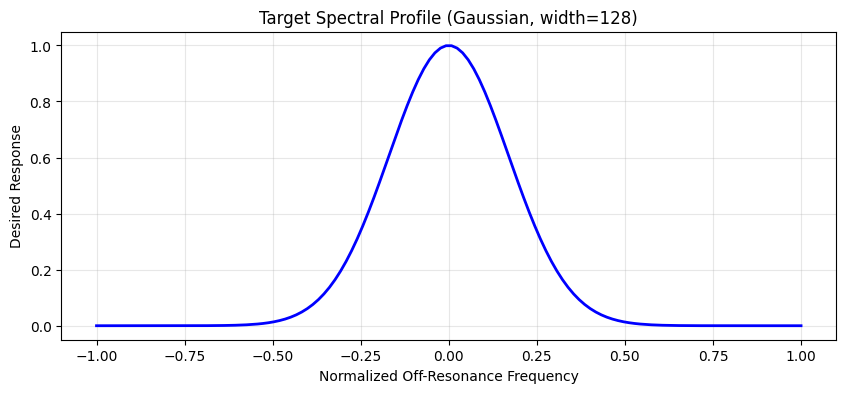

In [42]:
# Create Gaussian bandpass profile
desired_profile = responses.gaussian(WIDTH, bw=0.2, shift=0)
freq_axis = np.linspace(-1, 1, WIDTH)

plt.figure(figsize=(10, 4))
plt.plot(freq_axis, desired_profile, 'b-', linewidth=2)
plt.xlabel('Normalized Off-Resonance Frequency')
plt.ylabel('Desired Response')
plt.title(f'Target Spectral Profile (Gaussian, width={WIDTH})')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Simulate Spectral Data for Each Tissue Type

For each tissue, simulate SSFP signals across the off-resonance frequency range. This creates proper spectral data where each column corresponds to a specific frequency.

In [43]:
def simulate_tissue_spectral_data(T1, T2, params, width):
    """
    Simulate SSFP spectral response for a single tissue type.
    
    Returns: [1, width, n_features] array
    """
    return simulate_ssfp_simple(
        width=width, 
        height=1,
        T1=T1, 
        T2=T2,
        params=params,
        minTR=TRS[0]
    )

# Simulate spectral data for each tissue
tissue_data = {}
for name, props in TISSUES.items():
    data = simulate_tissue_spectral_data(props['T1'], props['T2'], params, WIDTH)
    tissue_data[name] = data
    print(f"{name:15s}: shape {data.shape}, signal range [{np.abs(data).min():.3f}, {np.abs(data).max():.3f}]")

CSF/Water      : shape (1, 128, 24), signal range [0.001, 0.354]
Fat            : shape (1, 128, 24), signal range [0.017, 0.263]
Gray Matter    : shape (1, 128, 24), signal range [0.005, 0.144]
White Matter   : shape (1, 128, 24), signal range [0.007, 0.165]
Muscle         : shape (1, 128, 24), signal range [0.005, 0.082]
Liver          : shape (1, 128, 24), signal range [0.009, 0.112]
Tendon         : shape (1, 128, 24), signal range [0.010, 0.040]


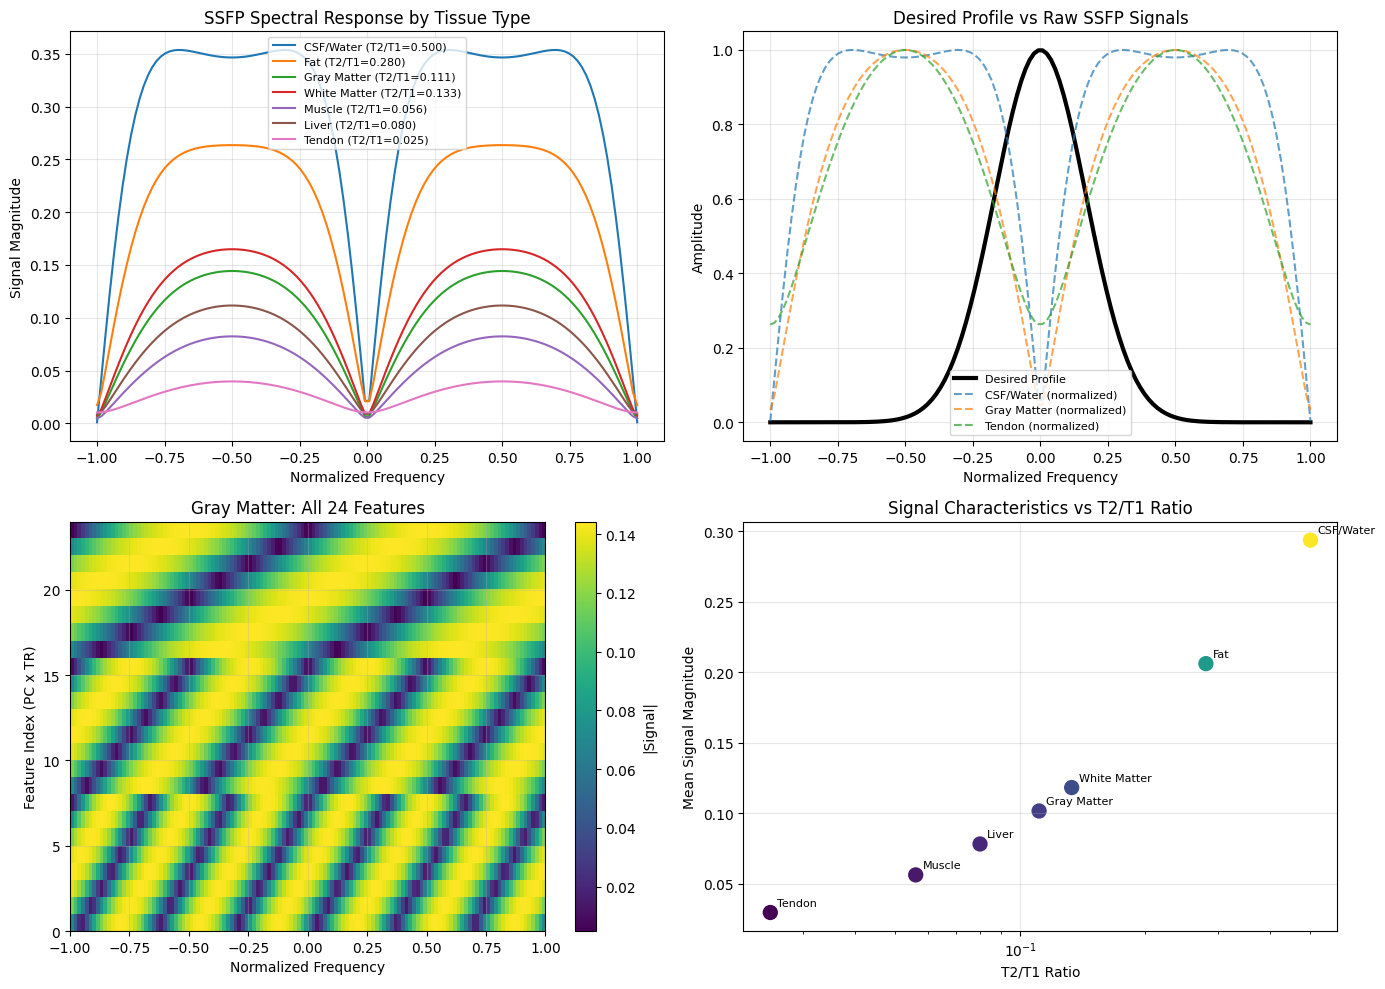

In [44]:
# Visualize spectral responses for different tissues
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot magnitude profiles for first phase cycle
ax = axes[0, 0]
for name, data in tissue_data.items():
    # Take first phase cycle of first TR
    signal_mag = np.abs(data[0, :, 0])
    ax.plot(freq_axis, signal_mag, label=f"{name} (T2/T1={TISSUES[name]['ratio']:.3f})")
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Signal Magnitude')
ax.set_title('SSFP Spectral Response by Tissue Type')
ax.legend(fontsize=8)

# Plot desired profile overlay
ax = axes[0, 1]
ax.plot(freq_axis, desired_profile, 'k-', linewidth=3, label='Desired Profile')
for name in ['CSF/Water', 'Gray Matter', 'Tendon']:
    signal_mag = np.abs(tissue_data[name][0, :, 0])
    # Normalize for comparison
    signal_norm = signal_mag / signal_mag.max()
    ax.plot(freq_axis, signal_norm, '--', alpha=0.7, label=f"{name} (normalized)")
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Amplitude')
ax.set_title('Desired Profile vs Raw SSFP Signals')
ax.legend(fontsize=8)

# Show full feature set for one tissue
ax = axes[1, 0]
sample_tissue = 'Gray Matter'
data = tissue_data[sample_tissue]
im = ax.imshow(np.abs(data[0]).T, aspect='auto', cmap='viridis',
               extent=[freq_axis[0], freq_axis[-1], 0, data.shape[-1]])
ax.set_xlabel('Normalized Frequency')
ax.set_ylabel('Feature Index (PC x TR)')
ax.set_title(f'{sample_tissue}: All {data.shape[-1]} Features')
plt.colorbar(im, ax=ax, label='|Signal|')

# T2/T1 ratio vs signal characteristics
ax = axes[1, 1]
ratios = [TISSUES[name]['ratio'] for name in TISSUES]
mean_signals = [np.abs(tissue_data[name]).mean() for name in TISSUES]
signal_stds = [np.abs(tissue_data[name]).std() for name in TISSUES]
ax.scatter(ratios, mean_signals, s=100, c=ratios, cmap='viridis')
for name, r, m in zip(TISSUES.keys(), ratios, mean_signals):
    ax.annotate(name, (r, m), fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('T2/T1 Ratio')
ax.set_ylabel('Mean Signal Magnitude')
ax.set_title('Signal Characteristics vs T2/T1 Ratio')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 5. Train Standard GASP (Single Model)

Train standard GASP on combined data from all tissues. This single model must handle all T2/T1 regimes with one set of coefficients.

In [45]:
# Stack all tissue data for combined training
# Shape: [n_tissues, WIDTH, n_features] -> [n_tissues, WIDTH, n_features]
all_tissue_names = list(tissue_data.keys())
combined_data = np.vstack([tissue_data[name] for name in all_tissue_names])
print(f"Combined data shape: {combined_data.shape}")
print(f"  {len(all_tissue_names)} tissues x {WIDTH} frequencies x {combined_data.shape[-1]} features")

Combined data shape: (7, 128, 24)
  7 tissues x 128 frequencies x 24 features


In [ ]:
# Train standard GASP on combined data
print("Training standard GASP on combined tissue data...")
standard_output, standard_coeffs = train_gasp(
    combined_data, 
    desired_profile,
    method='affine',
    useL2=True,
    lam=1e-2
)
print(f"Standard GASP coefficients: {standard_coeffs.shape}")
print(f"Output shape: {standard_output.shape}")

In [47]:
# Evaluate standard GASP per tissue
standard_results = {}

for i, name in enumerate(all_tissue_names):
    tissue_output = standard_output[i, :]  # Output for this tissue
    tissue_output_mag = np.abs(tissue_output)
    
    # Compute MSE against desired profile
    mse = np.mean((tissue_output_mag - desired_profile) ** 2)
    rmse = np.sqrt(mse)
    
    # Correlation
    corr = np.corrcoef(tissue_output_mag, desired_profile)[0, 1]
    
    standard_results[name] = {
        'output': tissue_output_mag,
        'mse': mse,
        'rmse': rmse,
        'correlation': corr,
        't2_t1_ratio': TISSUES[name]['ratio']
    }

print("Standard GASP Results per Tissue:")
print("-" * 60)
print(f"{'Tissue':<15} {'T2/T1':>8} {'RMSE':>10} {'Correlation':>12}")
print("-" * 60)
for name in sorted(standard_results.keys(), key=lambda x: -standard_results[x]['t2_t1_ratio']):
    r = standard_results[name]
    print(f"{name:<15} {r['t2_t1_ratio']:>8.3f} {r['rmse']:>10.4f} {r['correlation']:>12.4f}")

Standard GASP Results per Tissue:
------------------------------------------------------------
Tissue             T2/T1       RMSE  Correlation
------------------------------------------------------------
CSF/Water          0.500     0.0252       0.9999
Fat                0.280     0.0391       0.9986
White Matter       0.133     0.0456       0.9983
Gray Matter        0.111     0.0300       0.9989
Liver              0.080     0.0216       0.9986
Muscle             0.056     0.0722       0.9976
Tendon             0.025     0.1837       0.9917


## 6. Generate Training Data for MoE-GASP

For MoE-GASP, we need training samples with known T2/T1 ratios so the gating network can learn to route signals to appropriate experts.

In [ ]:
# Generate diverse training data for MoE-GASP
# Key insight: Using f0=0 (on-resonance) for training makes T2/T1 more distinguishable
# because the signal shape purely reflects T2/T1 without off-resonance confounding

print("Generating MoE-GASP training data...")

# Use f0_range=(0, 0) to generate on-resonance signals
# This removes off-resonance as a confounding variable for gating
moe_signals, moe_t2_t1_ratios, moe_params = generate_ssfp_training_data(
    n_samples=N_SAMPLES_PER_TISSUE * len(TISSUES),
    TR=TRS,
    alpha=ALPHA,
    npcs=N_PCS,
    t2_t1_range=(0.02, 0.6),  # Cover tissue range
    f0_range=(0, 0),  # On-resonance only - makes T2/T1 more distinguishable
    add_noise_flag=True,
    noise_sigma=0.005,
    seed=SEED
)

print(f"Generated {moe_signals.shape[0]} training samples")
print(f"Signal features: {moe_signals.shape[1]}")
print(f"T2/T1 range: [{moe_t2_t1_ratios.min():.3f}, {moe_t2_t1_ratios.max():.3f}]")
print(f"f0 range: on-resonance only (f0=0)")
print("\nNote: Using on-resonance signals for training because:")
print("  - Off-resonance variation confounds T2/T1 signal shape")
print("  - Gating should classify based on T2/T1, not off-resonance")
print("  - Normalized magnitude removes off-resonance phase effects")

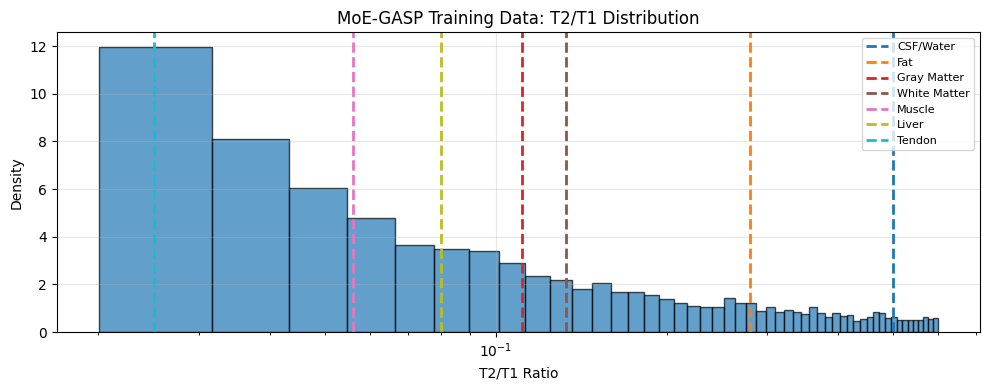

In [49]:
# Visualize T2/T1 distribution with tissue markers
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(moe_t2_t1_ratios, bins=50, edgecolor='black', alpha=0.7, density=True)
ax.set_xlabel('T2/T1 Ratio')
ax.set_ylabel('Density')
ax.set_title('MoE-GASP Training Data: T2/T1 Distribution')

# Mark tissue locations
colors = plt.cm.tab10(np.linspace(0, 1, len(TISSUES)))
for (name, props), color in zip(TISSUES.items(), colors):
    ax.axvline(props['ratio'], color=color, linestyle='--', linewidth=2, label=name)

ax.legend(loc='upper right', fontsize=8)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 7. Test Gating Networks

Test how well different gating architectures can classify signals by T2/T1 regime.

In [50]:
# Partition into regimes
n_experts = 5
regime_labels, regime_edges = partition_by_t2_t1(moe_t2_t1_ratios, n_regimes=n_experts)

print(f"Number of experts: {n_experts}")
print(f"Regime edges: {[f'{e:.3f}' for e in regime_edges]}")
print(f"Samples per regime: {[np.sum(regime_labels == k) for k in range(n_experts)]}")

Number of experts: 5
Regime edges: ['0.020', '0.039', '0.078', '0.152', '0.305', '0.600']
Samples per regime: [700, 700, 700, 700, 700]


In [ ]:
# Test gating networks with improved implementations
# The improvements include:
# - FeatureGating: More features (TR ratios, normalized shapes, skewness/kurtosis)
# - MLPGating: Input normalization, larger hidden layer, learning rate decay  
# - TemplateGating: Magnitude-only templates (avoids phase cancellation)

gating_networks = {
    'Feature': FeatureGating(n_experts, temperature=1.0, n_iterations=2000, learning_rate=0.1),
    'MLP': MLPGating(n_experts, hidden_dim=64, temperature=1.0, n_iterations=3000, learning_rate=0.01),
    'MLP-2Layer': MLPGating(n_experts, hidden_dim=64, temperature=1.0, n_iterations=3000, use_two_layers=True),
    'Template': TemplateGating(n_experts, temperature=0.5),
}

gating_accuracies = {}

for name, gating in gating_networks.items():
    gating.fit(moe_signals, regime_labels)
    weights = gating.predict_weights(moe_signals)
    predicted = np.argmax(weights, axis=1)
    accuracy = (predicted == regime_labels).mean()
    gating_accuracies[name] = accuracy
    print(f"{name:12s} Gating Accuracy: {accuracy:.1%}")

print("\n" + "="*50)
print("Note: Random baseline would be 20% (5 experts)")
print("="*50)

In [ ]:
# Visualize gating weights for best performing networks
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sort_idx = np.argsort(moe_t2_t1_ratios)
n_show = min(500, len(sort_idx))
show_idx = sort_idx[::max(1, len(sort_idx)//n_show)][:n_show]

for ax, (name, gating) in zip(axes.flat, gating_networks.items()):
    weights = gating.predict_weights(moe_signals[show_idx])
    im = ax.imshow(weights.T, aspect='auto', cmap='viridis')
    ax.set_xlabel('Sample (sorted by T2/T1)')
    ax.set_ylabel('Expert')
    ax.set_title(f'{name} Gating\nAccuracy: {gating_accuracies[name]:.1%}')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Also show confusion between regimes
print("\nConfusion Analysis (Best gating: Feature)")
best_gating = gating_networks['Feature']
weights = best_gating.predict_weights(moe_signals)
predicted = np.argmax(weights, axis=1)

from collections import Counter
print("\nPer-regime accuracy:")
for regime in range(n_experts):
    mask = regime_labels == regime
    regime_accuracy = (predicted[mask] == regime).mean()
    regime_t2_t1_range = (regime_edges[regime], regime_edges[regime+1])
    print(f"  Regime {regime} (T2/T1: {regime_t2_t1_range[0]:.3f}-{regime_t2_t1_range[1]:.3f}): {regime_accuracy:.1%}")

In [ ]:
# Diagnostic: Are the signals actually distinguishable by T2/T1 regime?
# Plot signal characteristics by regime

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Signal magnitude by regime
ax = axes[0, 0]
for regime in range(n_experts):
    mask = regime_labels == regime
    mean_mag = np.abs(moe_signals[mask]).mean(axis=0)
    ax.plot(mean_mag, label=f'Regime {regime}', alpha=0.8)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Mean Magnitude')
ax.set_title('Mean Signal Magnitude by Regime')
ax.legend(fontsize=8)

# Normalized signal shape by regime  
ax = axes[0, 1]
for regime in range(n_experts):
    mask = regime_labels == regime
    mag = np.abs(moe_signals[mask])
    mag_norm = mag / mag.sum(axis=1, keepdims=True)
    mean_shape = mag_norm.mean(axis=0)
    ax.plot(mean_shape, label=f'Regime {regime}', alpha=0.8)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Normalized Shape')
ax.set_title('Mean Normalized Shape by Regime\n(This is what gating sees)')
ax.legend(fontsize=8)

# TR decay ratios by regime
ax = axes[0, 2]
n_pcs = moe_signals.shape[1] // 3
regime_centers = []
decay_ratios = []
for regime in range(n_experts):
    mask = regime_labels == regime
    mag = np.abs(moe_signals[mask])
    tr1_mean = mag[:, :n_pcs].mean(axis=1)
    tr2_mean = mag[:, n_pcs:2*n_pcs].mean(axis=1)
    ratio = tr2_mean / np.maximum(tr1_mean, 1e-10)
    regime_centers.append(np.sqrt(regime_edges[regime] * regime_edges[regime+1]))
    decay_ratios.append(ratio.mean())
ax.scatter(regime_centers, decay_ratios, s=100)
for i, (x, y) in enumerate(zip(regime_centers, decay_ratios)):
    ax.annotate(f'R{i}', (x, y), fontsize=10, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('T2/T1 Ratio (log scale)')
ax.set_ylabel('TR Decay Ratio')
ax.set_title('TR Decay Ratio vs T2/T1\n(Should show correlation)')
ax.set_xscale('log')

# Distribution of signal features by regime
ax = axes[1, 0]
# Use first PC signal magnitude as a simple feature
feature_values = np.abs(moe_signals[:, 0])
for regime in range(n_experts):
    mask = regime_labels == regime
    ax.hist(feature_values[mask], bins=30, alpha=0.5, label=f'Regime {regime}', density=True)
ax.set_xlabel('First PC Signal Magnitude')
ax.set_ylabel('Density')
ax.set_title('Feature Distribution by Regime')
ax.legend(fontsize=8)

# PCA visualization
ax = axes[1, 1]
mag = np.abs(moe_signals)
mag_norm = mag / mag.sum(axis=1, keepdims=True)
# Simple 2D projection using first 2 PCs
U, S, Vt = np.linalg.svd(mag_norm - mag_norm.mean(axis=0), full_matrices=False)
projected = U[:, :2] * S[:2]
scatter = ax.scatter(projected[:, 0], projected[:, 1], c=regime_labels, cmap='tab10', alpha=0.5, s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of Normalized Signals\n(Colored by regime)')
plt.colorbar(scatter, ax=ax, label='Regime')

# Separability metric
ax = axes[1, 2]
# Compute between-class vs within-class variance (Fisher criterion)
overall_mean = mag_norm.mean(axis=0)
between_var = 0
within_var = 0
for regime in range(n_experts):
    mask = regime_labels == regime
    regime_mean = mag_norm[mask].mean(axis=0)
    between_var += mask.sum() * np.sum((regime_mean - overall_mean)**2)
    within_var += np.sum((mag_norm[mask] - regime_mean)**2)
    
fisher_ratio = between_var / (within_var + 1e-10)
ax.bar(['Fisher Ratio'], [fisher_ratio], color='steelblue')
ax.set_ylabel('Ratio')
ax.set_title(f'Class Separability\n(Higher = more separable)')
ax.text(0, fisher_ratio/2, f'{fisher_ratio:.4f}', ha='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSeparability Analysis:")
print(f"  Fisher Ratio: {fisher_ratio:.4f}")
print(f"  (Values > 0.1 suggest reasonable separability)")
print(f"  (Values < 0.01 indicate signals are very similar across regimes)")

## 8. Train MoE-GASP

In [ ]:
# Configure MoE-GASP
config = MoEGASPConfig(
    n_experts=5,
    method='affine',
    gating_type='mlp',
    gating_temperature=1.0,
    useL2=True,
    lam=1e-2
)

print("MoE-GASP Configuration:")
for field in ['n_experts', 'method', 'gating_type', 'gating_temperature', 'useL2', 'lam']:
    print(f"  {field}: {getattr(config, field)}")

In [54]:
# Train MoE-GASP
print("Training MoE-GASP...")
moe_model = train_moe_gasp(moe_signals, desired_profile, moe_t2_t1_ratios, config)

print(f"\nTraining complete!")
print(f"  Samples per regime: {moe_model.training_info['samples_per_regime']}")
print(f"  Regime edges: {[f'{e:.3f}' for e in moe_model.regime_edges]}")

Training MoE-GASP...

Training complete!
  Samples per regime: [700, 700, 700, 700, 700]
  Regime edges: ['0.020', '0.039', '0.078', '0.152', '0.305', '0.600']


## 9. Evaluate MoE-GASP on Each Tissue Type

Apply both standard GASP and MoE-GASP to each tissue's spectral data and compare results.

In [55]:
# Evaluate MoE-GASP per tissue
moe_results = {}

for name, data in tissue_data.items():
    # Apply MoE-GASP
    moe_output, moe_weights = run_moe_gasp(data, moe_model)
    moe_output_mag = np.abs(moe_output[0, :])  # [1, WIDTH] -> [WIDTH]
    
    # Compute metrics
    mse = np.mean((moe_output_mag - desired_profile) ** 2)
    rmse = np.sqrt(mse)
    corr = np.corrcoef(moe_output_mag, desired_profile)[0, 1]
    
    # Get dominant expert for this tissue
    mean_weights = moe_weights[0].mean(axis=0)  # Average across frequencies
    dominant_expert = np.argmax(mean_weights)
    
    moe_results[name] = {
        'output': moe_output_mag,
        'mse': mse,
        'rmse': rmse,
        'correlation': corr,
        'dominant_expert': dominant_expert,
        'expert_weights': mean_weights,
        't2_t1_ratio': TISSUES[name]['ratio']
    }

In [56]:
# Compare results
print("\n" + "="*80)
print("COMPARISON: Standard GASP vs MoE-GASP")
print("="*80)
print(f"{'Tissue':<15} {'T2/T1':>7} {'Std RMSE':>10} {'MoE RMSE':>10} {'Improvement':>12} {'Expert':>7}")
print("-"*80)

improvements = []
for name in sorted(moe_results.keys(), key=lambda x: -moe_results[x]['t2_t1_ratio']):
    std_r = standard_results[name]
    moe_r = moe_results[name]
    
    improvement = (std_r['rmse'] - moe_r['rmse']) / std_r['rmse'] * 100
    improvements.append(improvement)
    
    print(f"{name:<15} {moe_r['t2_t1_ratio']:>7.3f} {std_r['rmse']:>10.4f} {moe_r['rmse']:>10.4f} "
          f"{improvement:>+11.1f}% {moe_r['dominant_expert']:>7}")

print("-"*80)
print(f"{'Average':<15} {'':<7} {np.mean([r['rmse'] for r in standard_results.values()]):>10.4f} "
      f"{np.mean([r['rmse'] for r in moe_results.values()]):>10.4f} "
      f"{np.mean(improvements):>+11.1f}%")
print("="*80)


COMPARISON: Standard GASP vs MoE-GASP
Tissue            T2/T1   Std RMSE   MoE RMSE  Improvement  Expert
--------------------------------------------------------------------------------
CSF/Water         0.500     0.0252     0.4334     -1619.7%       4
Fat               0.280     0.0391     0.3555      -808.5%       4
White Matter      0.133     0.0456     0.3223      -606.6%       4
Gray Matter       0.111     0.0300     0.3197      -965.0%       4
Liver             0.080     0.0216     0.3170     -1366.8%       4
Muscle            0.056     0.0722     0.3172      -339.1%       4
Tendon            0.025     0.1837     0.3183       -73.3%       1
--------------------------------------------------------------------------------
Average                     0.0596     0.3405      -825.6%


## 10. Visualize Spectral Profile Quality

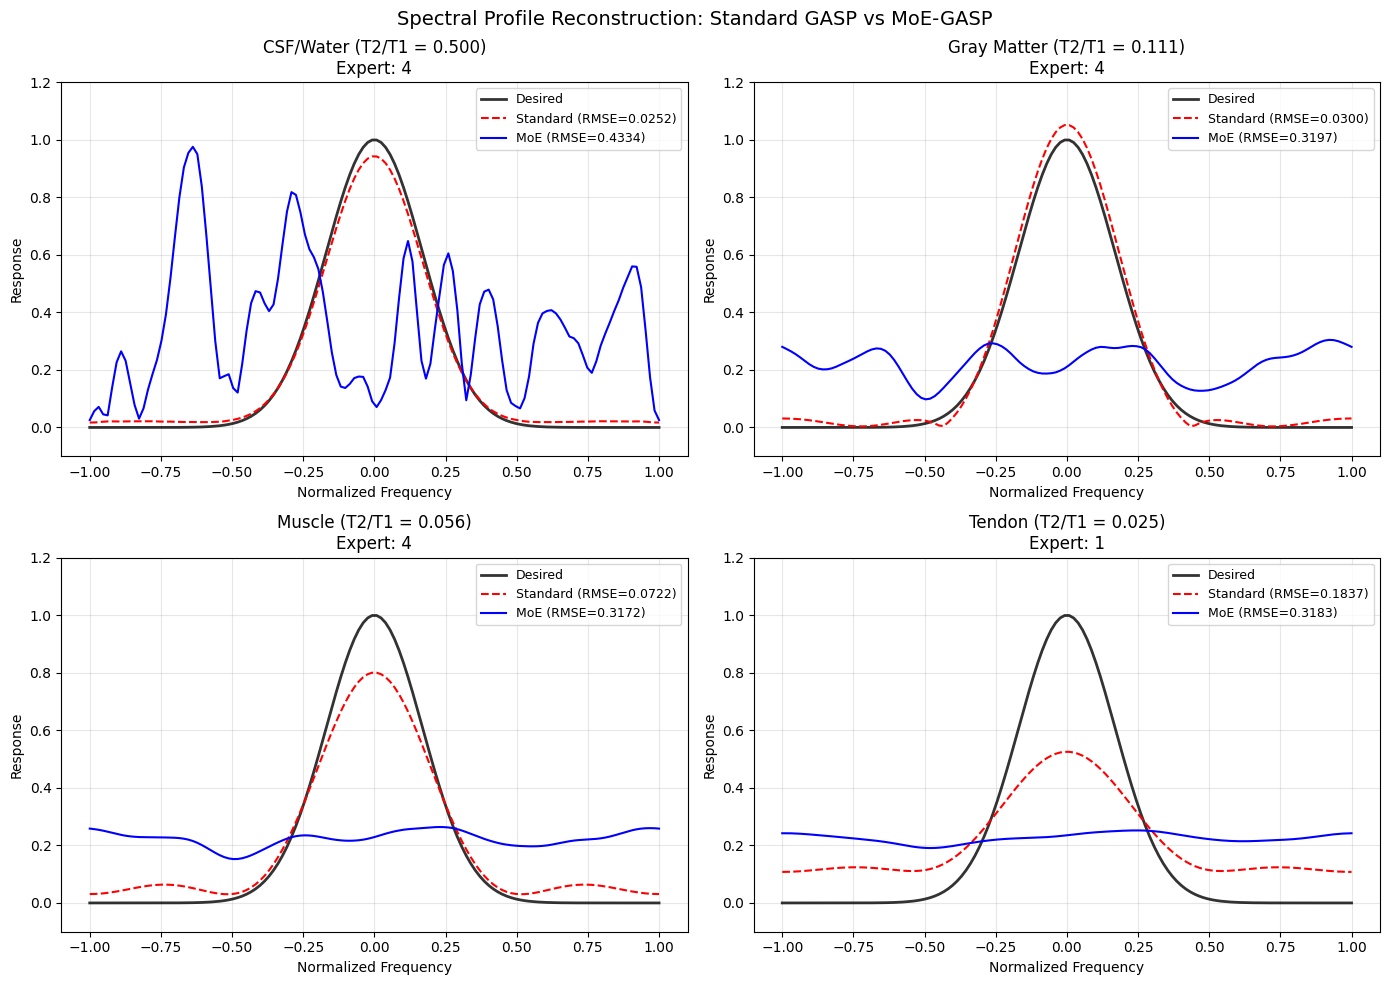

In [57]:
# Plot spectral profiles for selected tissues
selected_tissues = ['CSF/Water', 'Gray Matter', 'Muscle', 'Tendon']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flat, selected_tissues):
    std_out = standard_results[name]['output']
    moe_out = moe_results[name]['output']
    
    ax.plot(freq_axis, desired_profile, 'k-', linewidth=2, label='Desired', alpha=0.8)
    ax.plot(freq_axis, std_out, 'r--', linewidth=1.5, label=f'Standard (RMSE={standard_results[name]["rmse"]:.4f})')
    ax.plot(freq_axis, moe_out, 'b-', linewidth=1.5, label=f'MoE (RMSE={moe_results[name]["rmse"]:.4f})')
    
    ax.set_xlabel('Normalized Frequency')
    ax.set_ylabel('Response')
    ax.set_title(f'{name} (T2/T1 = {TISSUES[name]["ratio"]:.3f})\nExpert: {moe_results[name]["dominant_expert"]}')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim([-0.1, 1.2])

plt.suptitle('Spectral Profile Reconstruction: Standard GASP vs MoE-GASP', fontsize=14)
plt.tight_layout()
plt.show()

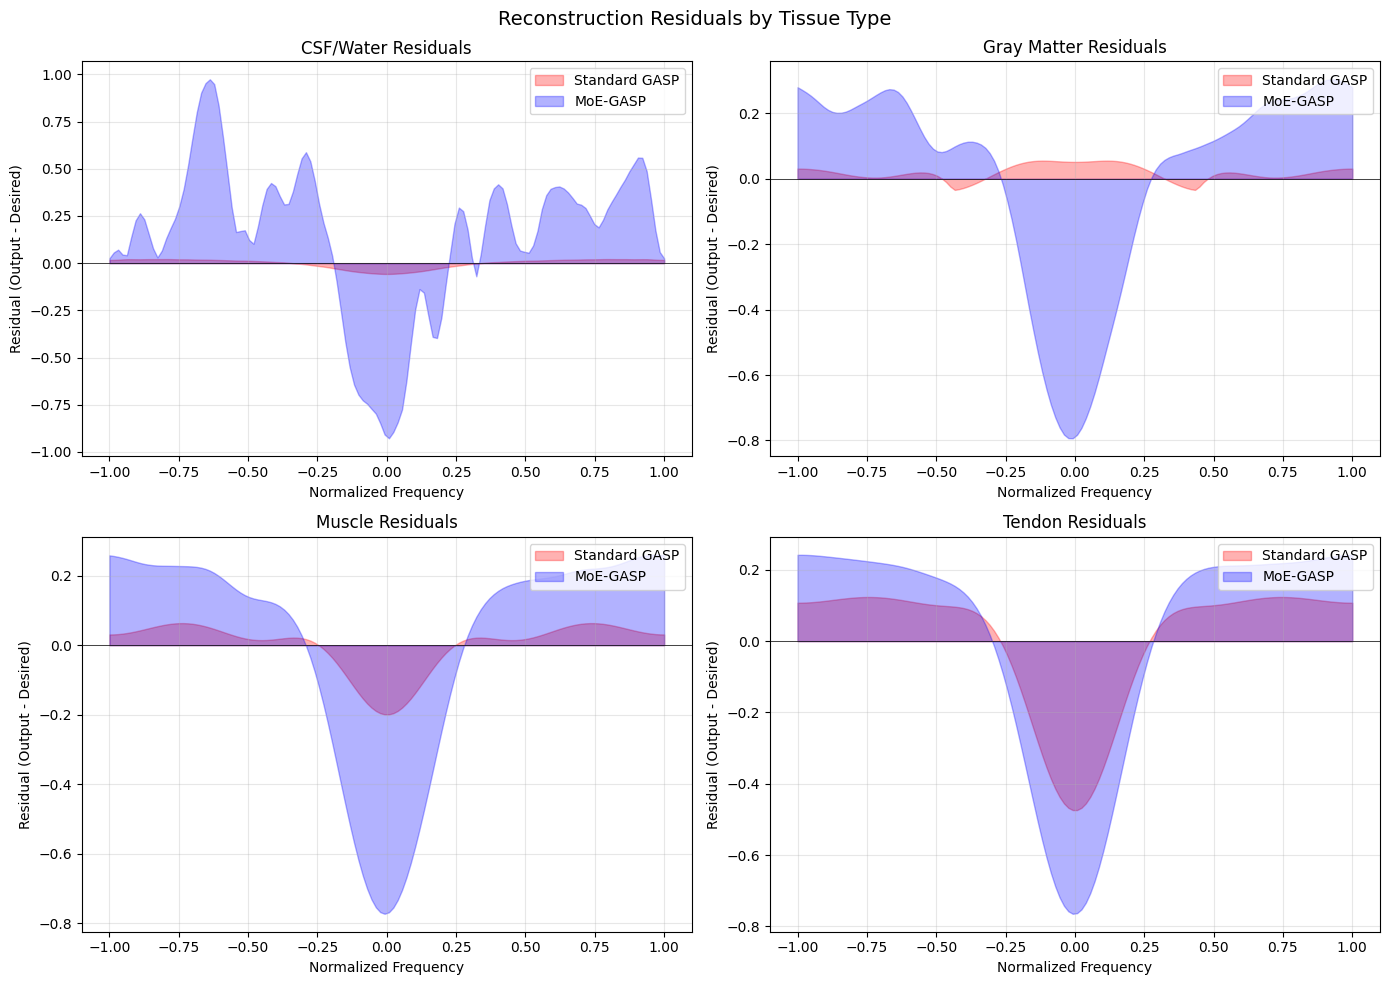

In [58]:
# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name in zip(axes.flat, selected_tissues):
    std_residual = standard_results[name]['output'] - desired_profile
    moe_residual = moe_results[name]['output'] - desired_profile
    
    ax.fill_between(freq_axis, 0, std_residual, alpha=0.3, color='red', label='Standard GASP')
    ax.fill_between(freq_axis, 0, moe_residual, alpha=0.3, color='blue', label='MoE-GASP')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
    
    ax.set_xlabel('Normalized Frequency')
    ax.set_ylabel('Residual (Output - Desired)')
    ax.set_title(f'{name} Residuals')
    ax.legend()

plt.suptitle('Reconstruction Residuals by Tissue Type', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Expert Activation Analysis

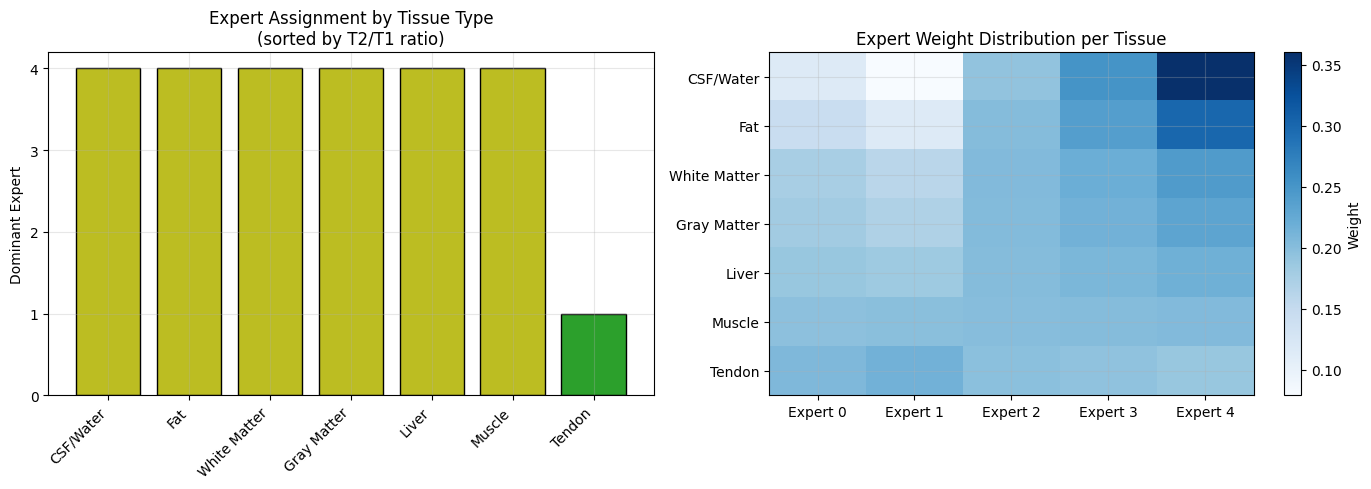

In [59]:
# Plot expert weights per tissue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of dominant expert per tissue
ax = axes[0]
tissue_names = sorted(moe_results.keys(), key=lambda x: -moe_results[x]['t2_t1_ratio'])
t2_t1_values = [moe_results[name]['t2_t1_ratio'] for name in tissue_names]
dominant_experts = [moe_results[name]['dominant_expert'] for name in tissue_names]

colors = plt.cm.tab10(np.array(dominant_experts) / config.n_experts)
bars = ax.bar(range(len(tissue_names)), dominant_experts, color=colors, edgecolor='black')
ax.set_xticks(range(len(tissue_names)))
ax.set_xticklabels(tissue_names, rotation=45, ha='right')
ax.set_ylabel('Dominant Expert')
ax.set_title('Expert Assignment by Tissue Type\n(sorted by T2/T1 ratio)')
ax.set_yticks(range(config.n_experts))

# Heatmap of expert weights
ax = axes[1]
weight_matrix = np.array([moe_results[name]['expert_weights'] for name in tissue_names])
im = ax.imshow(weight_matrix, aspect='auto', cmap='Blues')
ax.set_xticks(range(config.n_experts))
ax.set_xticklabels([f'Expert {i}' for i in range(config.n_experts)])
ax.set_yticks(range(len(tissue_names)))
ax.set_yticklabels(tissue_names)
ax.set_title('Expert Weight Distribution per Tissue')
plt.colorbar(im, ax=ax, label='Weight')

plt.tight_layout()
plt.show()

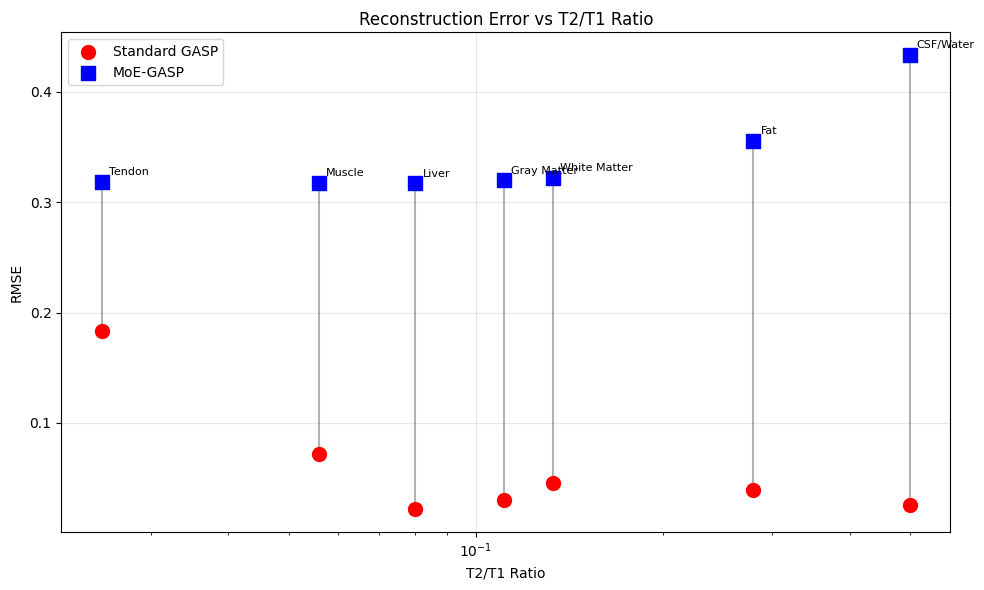

In [60]:
# Plot RMSE vs T2/T1 ratio
fig, ax = plt.subplots(figsize=(10, 6))

t2_t1 = [moe_results[name]['t2_t1_ratio'] for name in tissue_names]
std_rmse = [standard_results[name]['rmse'] for name in tissue_names]
moe_rmse = [moe_results[name]['rmse'] for name in tissue_names]

ax.scatter(t2_t1, std_rmse, s=100, c='red', marker='o', label='Standard GASP', zorder=3)
ax.scatter(t2_t1, moe_rmse, s=100, c='blue', marker='s', label='MoE-GASP', zorder=3)

# Connect with lines
for x, y1, y2, name in zip(t2_t1, std_rmse, moe_rmse, tissue_names):
    ax.plot([x, x], [y1, y2], 'k-', alpha=0.3)
    ax.annotate(name, (x, max(y1, y2)), fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('T2/T1 Ratio')
ax.set_ylabel('RMSE')
ax.set_title('Reconstruction Error vs T2/T1 Ratio')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Summary

In [ ]:
print("="*70)
print("MoE-GASP EVALUATION SUMMARY")
print("="*70)

print(f"\nConfiguration:")
print(f"  - Spectral width: {WIDTH} frequency points")
print(f"  - Acquisition: {N_PCS} PCs x {N_TRS} TRs")
print(f"  - Number of experts: {config.n_experts}")
print(f"  - Gating type: {config.gating_type}")
print(f"  - Method: {config.method}")

print(f"\nGating Network Accuracies (on training data):")
for name, acc in gating_accuracies.items():
    marker = " <-- Best" if acc == max(gating_accuracies.values()) else ""
    print(f"  - {name:12s}: {acc:.1%}{marker}")
print(f"  - Random baseline: 20.0% (5 experts)")

print(f"\nReconstruction Quality (RMSE):")
std_mean = np.mean([r['rmse'] for r in standard_results.values()])
moe_mean = np.mean([r['rmse'] for r in moe_results.values()])
print(f"  - Standard GASP (mean): {std_mean:.4f}")
print(f"  - MoE-GASP (mean):      {moe_mean:.4f}")
improvement = (std_mean - moe_mean) / std_mean * 100
print(f"  - Mean improvement:     {improvement:+.1f}%")

# Find best/worst improvements
improvements_dict = {name: (standard_results[name]['rmse'] - moe_results[name]['rmse']) / standard_results[name]['rmse'] * 100
                     for name in tissue_names}
best_tissue = max(improvements_dict, key=improvements_dict.get)
worst_tissue = min(improvements_dict, key=improvements_dict.get)

print(f"\nPer-tissue analysis:")
print(f"  Best improvement:  {best_tissue} ({improvements_dict[best_tissue]:+.1f}%)")
print(f"  Worst improvement: {worst_tissue} ({improvements_dict[worst_tissue]:+.1f}%)")

print(f"\nKey Observations:")
if improvement > 0:
    print(f"  ✓ MoE-GASP outperforms standard GASP on average")
else:
    print(f"  ✗ MoE-GASP underperforms - gating accuracy may be insufficient")
    print(f"    Consider: more training data, fewer experts, or different features")

best_gating_acc = max(gating_accuracies.values())
if best_gating_acc > 0.5:
    print(f"  ✓ Gating accuracy ({best_gating_acc:.1%}) indicates good regime separation")
elif best_gating_acc > 0.3:
    print(f"  ~ Moderate gating accuracy ({best_gating_acc:.1%}) - some confusion between regimes")
else:
    print(f"  ✗ Low gating accuracy ({best_gating_acc:.1%}) - T2/T1 regimes hard to distinguish")
    print(f"    This is a fundamental limitation of the signal structure")

print("="*70)